<div style="
  background: #0f1117;
  border-radius: 18px;
  padding: 28px 32px;
  color: #e6e6e6;
  box-shadow: 0 10px 30px rgba(0,0,0,0.6);
  border: 1px solid rgba(255,255,255,0.06);
  margin-bottom: 28px;
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
">
  <div style="font-size: 34px; font-weight: 700; letter-spacing: -0.3px;">
    Predicting Uber Ride Cancellations 🚗
  </div>

  <div style="
    margin-top: 10px;
    font-size: 17px;
    color: #b5b5b5;
    max-width: 900px;
    line-height: 1.6;
  ">
    A fast, interpretable machine learning pipeline to predict customer ride cancellations using Logistic, Random Forest, XGBoost.
  </div>
</div>


<div style="
  background: #0f1117;
  border-radius: 18px;
  padding: 26px 32px;
  color: #e6e6e6;
  box-shadow: 0 10px 30px rgba(0,0,0,0.6);
  border: 1px solid rgba(255,255,255,0.06);
  margin-bottom: 28px;
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
">

  <div style="
    font-size: 26px;
    font-weight: 700;
    margin-bottom: 12px;
    letter-spacing: -0.2px;
  ">
    Introduction: Why This Matters 💡
  </div>

  <div style="
    font-size: 16.5px;
    line-height: 1.65;
    color: #cfcfcf;
    max-width: 900px;
  ">
    Every cancelled ride represents lost revenue, wasted driver time, and a signal of potential customer churn.
  </div>

  <div style="
    margin-top: 14px;
    font-size: 16.5px;
    line-height: 1.65;
    color: #cfcfcf;
    max-width: 900px;
  ">
    By predicting ride cancellations before they occur, ride-hailing platforms can:
  </div>

  <ul style="
    margin-top: 12px;
    font-size: 16.5px;
    line-height: 1.9;
    color: #e0e0e0;
  ">
    <li>Improve customer experience through proactive interventions</li>
    <li>Optimize driver dispatch and resource allocation</li>
    <li>Reduce operational inefficiencies and idle time</li>
  </ul>

  <div style="
    margin-top: 14px;
    font-size: 15.5px;
    color: #a8a8a8;
    max-width: 900px;
  ">
    This notebook flags cancellations using only pre-ride information, avoiding data leakage while maintaining interpretability.
  </div>

</div>


<div style="
  background:#0f1117;
  border-radius:18px;
  padding:26px 32px;
  color:#e6e6e6;
  box-shadow:0 10px 30px rgba(0,0,0,0.6);
  border:1px solid rgba(255,255,255,0.06);
  margin-bottom:28px;
  font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;
">

  <div style="font-size:26px;font-weight:700;letter-spacing:-0.2px;margin-bottom:10px;">
    Problem Statement 📌
  </div>

  <div style="height:3px;width:60px;background:#3b82f6;border-radius:2px;margin-bottom:16px;"></div>

  <div style="font-size:16.5px;line-height:1.65;color:#cfcfcf;max-width:900px;">
    Can we predict whether a customer will cancel an Uber ride <b>before it begins</b>, using only information available at booking time?
  </div>

  <div style="margin-top:12px;font-size:16px;line-height:1.6;color:#cfcfcf;max-width:900px;">
    <b>Task:</b> Binary classification<br/>
    <b>Target variable:</b>
    <span style="
      background:#1f2933;
      color:#ffffff;
      font-weight:700;
      padding:4px 8px;
      border-radius:6px;
      font-family:ui-monospace,SFMono-Regular,Menlo,Monaco,Consolas,'Liberation Mono','Courier New',monospace;
      font-size:0.95em;
      display:inline-block;
      vertical-align:baseline;
    ">target_customer_cancelled</span>
    <span style="color:#cfcfcf;">
      (1 = cancelled by customer, 0 = not cancelled)
    </span>
  </div>

  <div style="margin-top:14px;font-size:15.5px;color:#a8a8a8;max-width:900px;">
    Note: The target variable is highly imbalanced, with customer cancellations accounting for approximately 7% of all bookings.
  </div>

</div>


<div style="
  background:#0f1117;
  border-radius:18px;
  padding:26px 32px;
  color:#e6e6e6;
  box-shadow:0 10px 30px rgba(0,0,0,0.6);
  border:1px solid rgba(255,255,255,0.06);
  margin-bottom:28px;
  font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;
">

  <div style="font-size:26px;font-weight:700;letter-spacing:-0.2px;margin-bottom:10px;">
    About the Dataset 📊
  </div>

  <div style="height:3px;width:60px;background:#3b82f6;border-radius:2px;margin-bottom:16px;"></div>

  <ul style="font-size:16.5px;line-height:1.9;color:#cfcfcf;max-width:900px;">
    <li><b>Dataset:</b> Uber Ride Analytics (2024)</li>
    <li><b>Observations:</b> Approximately 150,000 ride bookings</li>
    <li>
      <b>Target construction:</b> Derived from the original booking status field and mapped to
      <span style="
        background:#1f2933;
        color:#ffffff;
        font-weight:700;
        padding:4px 8px;
        border-radius:6px;
        font-family:ui-monospace,SFMono-Regular,Menlo,Monaco,Consolas,'Liberation Mono','Courier New',monospace;
        font-size:0.95em;
        display:inline-block;
        vertical-align:baseline;
      ">
        target_customer_cancelled
      </span>
    </li>
    <li>
      <b>Features:</b> Booking-time metadata including time of day, vehicle type,
      pickup and drop-off locations, estimated distances, and historical user/driver ratings
    </li>
    <li>
      <b>Data quality:</b> Well-structured with limited missing values; additional indicators
      are created to track missingness where relevant
    </li>
  </ul>

</div>


<div style="
  background:#0f1117;
  border-radius:18px;
  padding:26px 32px;
  color:#e6e6e6;
  box-shadow:0 10px 30px rgba(0,0,0,0.6);
  border:1px solid rgba(255,255,255,0.06);
  margin-bottom:28px;
  font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,Helvetica,Arial,sans-serif;
">

  <div style="font-size:26px;font-weight:700;letter-spacing:-0.2px;margin-bottom:10px;">
    About the Author 💁‍♂️
  </div>

  <div style="height:3px;width:60px;background:#3b82f6;border-radius:2px;margin-bottom:16px;"></div>

  <div style="font-size:16.5px;line-height:1.65;color:#cfcfcf;max-width:900px;">
    I am a Computer Science student with a strong interest in data science and machine learning,
    focused on building interpretable and practical models for real-world problems.
  </div>

  <div style="margin-top:12px;font-size:16.5px;line-height:1.65;color:#cfcfcf;max-width:900px;">
    This project reflects my approach to applied machine learning: understanding the business
    context, preventing data leakage, and designing models that can realistically be deployed
    in production environments.
  </div>

  <div style="margin-top:18px;font-size:15.5px;color:#a8a8a8;">
    Connect:
    <a href=https://www.linkedin.com/in/lho1/ target="_blank" style="color:#3b82f6;text-decoration:none;font-weight:600;">LinkedIn</a>
  </div>

</div>


# Download Important Libraries

In [1]:
import sys
!{sys.executable} -m pip install seaborn matplotlib scikit-learn numpy xgboost

import pandas as pd

df = pd.read_csv("ncr_ride_bookings.csv")
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


# Printing Data Type and Information

In [2]:
print("Data types: ")
print()
df.info()


Data types: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by 

# Data Summary, Null Values

In [3]:
print("Data Statistics:\n")
df.describe(include="all")

Data Statistics:



,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
count,150000,150000,150000,150000,150000,150000,150000,150000,139500.000000,102000.000000,...,10500,27000.0,27000,9000.0,9000,102000.000000,102000.000000,93000.000000,93000.000000,102000
unique,365,62910,148767,5,148788,7,176,176,NaN,NaN,...,5,NaN,4,NaN,3,NaN,NaN,NaN,NaN,5
top,2024-11-16,17:44:57,"""CNR7908610""",Completed,"""CID4523979""",Auto,Khandsa,Ashram,NaN,NaN,...,Wrong Address,NaN,Customer related issue,NaN,Customer Demand,NaN,NaN,NaN,NaN,UPI
freq,462,16,3,93000,3,37419,949,936,NaN,NaN,...,2362,NaN,6837,NaN,3040,NaN,NaN,NaN,NaN,45909
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456352,29.149636,...,NaN,1.0,NaN,1.0,NaN,508.295912,24.637012,4.230992,4.404584,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,...,NaN,0.0,NaN,0.0,NaN,395.805774,14.002138,0.436871,0.437819,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,10.000000,...,NaN,1.0,NaN,1.0,NaN,50.000000,1.000000,3.000000,3.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300000,21.600000,...,NaN,1.0,NaN,1.0,NaN,234.000000,12.460000,4.100000,4.200000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,28.800000,...,NaN,1.0,NaN,1.0,NaN,414.000000,23.720000,4.300000,4.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.300000,36.800000,...,NaN,1.0,NaN,1.0,NaN,689.000000,36.820000,4.600000,4.800000,NaN


In [4]:
print("Data Null Values:\n")
df.isnull().sum()

Data Null Values:



Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [5]:
df["Booking Status"].value_counts()



Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

# Creating a binary target variable and verifying class weight


In [6]:
df["target_customer_cancelled"] = df["Booking Status"].apply(
    lambda x: 1 if x == "Cancelled by Customer" else 0
)


In [7]:
df["target_customer_cancelled"].value_counts(normalize=True)

# 0 is completed
# 1 is not completed


target_customer_cancelled
0    0.93
1    0.07
Name: proportion, dtype: float64

# Date Time Parsing

In [8]:
df["Date"] = pd.to_datetime(df['Date'], errors = 'coerce')
df["Time"] = pd.to_datetime(df["Time"], format = "%H:%M:%S", errors = 'coerce').dt.time

df["datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors = 'coerce')

df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["weekday"] = df["datetime"].dt.dayofweek #Monday = 0, Sunday = 6
df["is_weekend"] = df["weekday"].isin([5,6])

print(df[["datetime","hour","day","month","weekday","is_weekend"]].head())

             datetime  hour  day  month  weekday  is_weekend
0 2024-03-23 12:29:38    12   23      3        5        True
1 2024-11-29 18:01:39    18   29     11        4       False
2 2024-08-23 08:56:10     8   23      8        4       False
3 2024-10-21 17:17:25    17   21     10        0       False
4 2024-09-16 22:08:00    22   16      9        0       False


In [9]:
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].median())
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].median())


# EDA

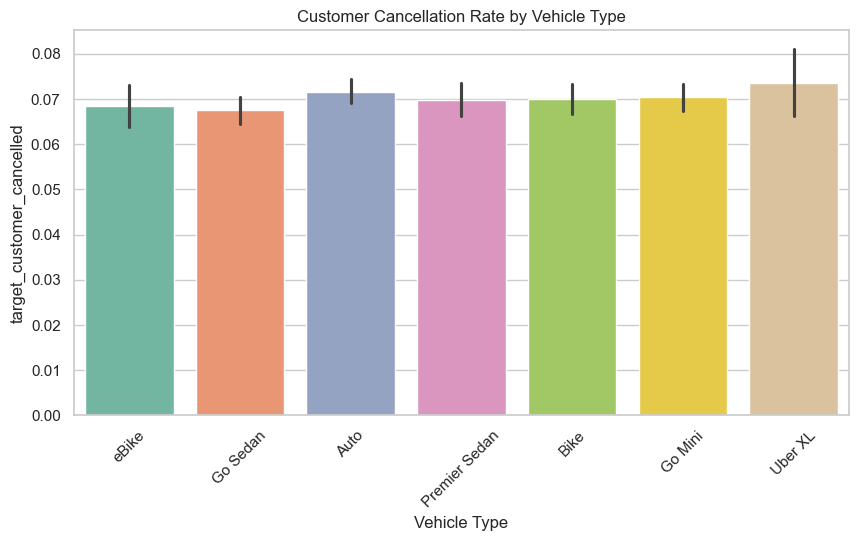

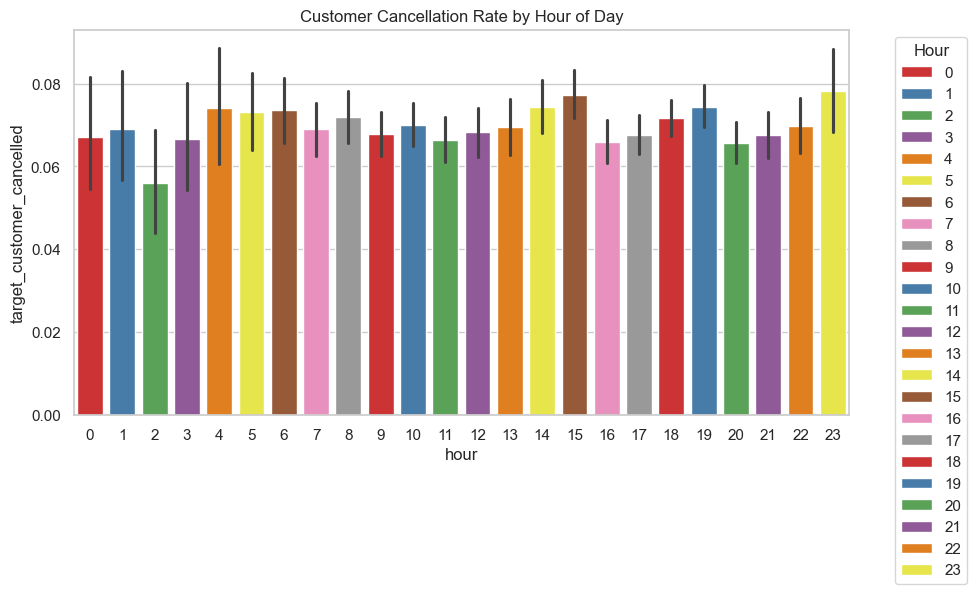

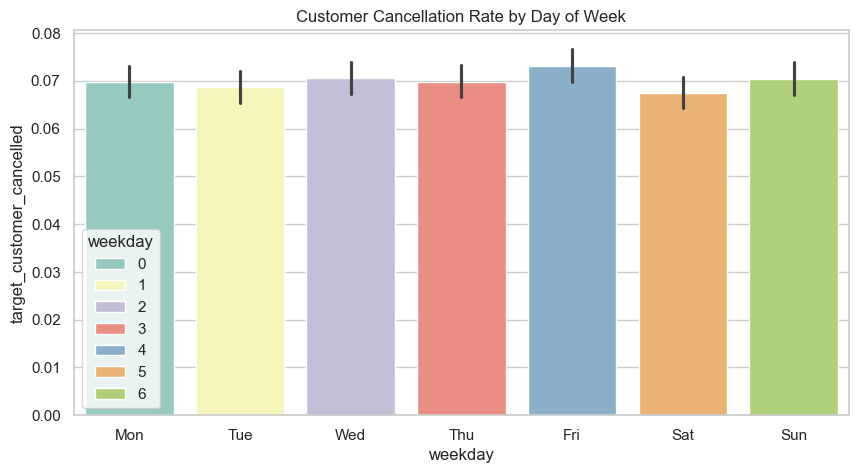

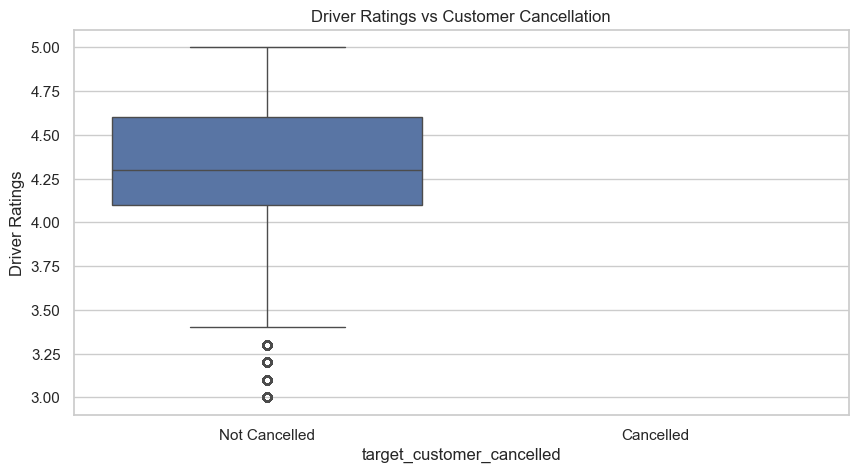

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10,5))
sns.barplot(data = df, x ="Vehicle Type", y="target_customer_cancelled", hue='Vehicle Type', palette ="Set2")
plt.title("Customer Cancellation Rate by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='hour', y='target_customer_cancelled', hue='hour', palette ="Set1")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Hour")
plt.title("Customer Cancellation Rate by Hour of Day")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='weekday', y='target_customer_cancelled', hue='weekday', palette ="Set3")
plt.title("Customer Cancellation Rate by Day of Week")
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='target_customer_cancelled', y='Driver Ratings')
plt.title("Driver Ratings vs Customer Cancellation")
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.show()

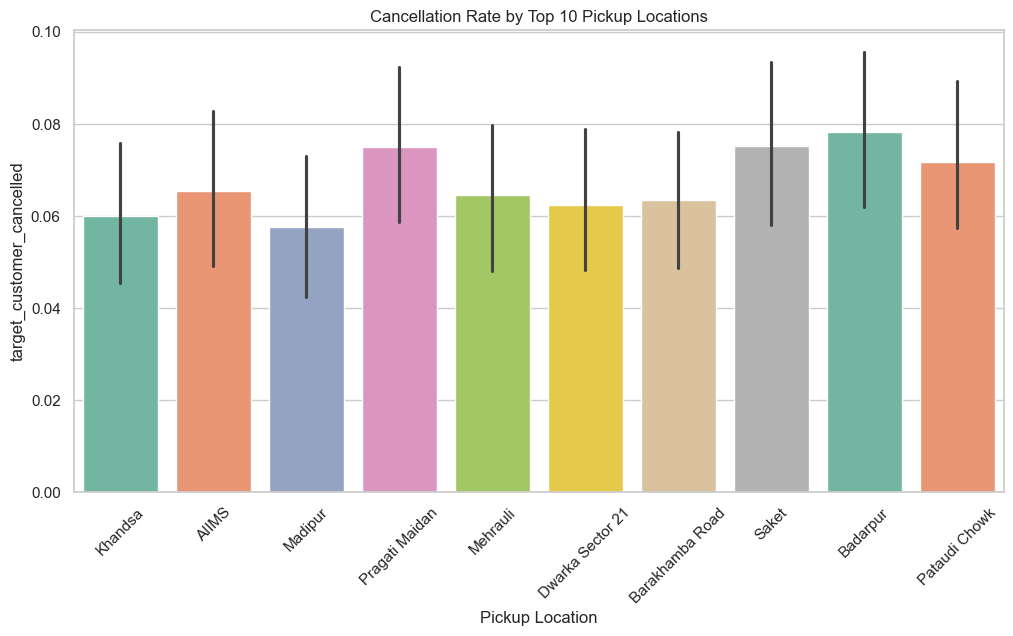

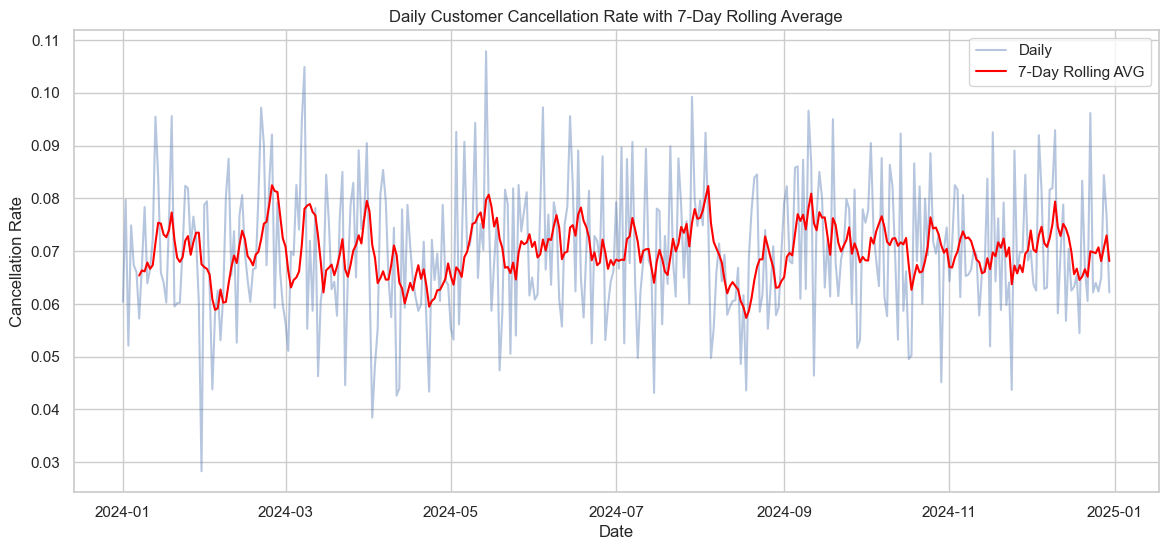

In [11]:
top_pickups = df['Pickup Location'].value_counts().nlargest(10).index
df_top_pickups = df[df['Pickup Location'].isin(top_pickups)]

plt.figure(figsize=(12,6))
sns.barplot(data = df_top_pickups, x = 'Pickup Location', y='target_customer_cancelled', hue='Pickup Location', palette ="Set2")
plt.title("Cancellation Rate by Top 10 Pickup Locations")
plt.xticks(rotation=45)
plt.show()

df_daily = df.groupby('Date')['target_customer_cancelled'].mean().reset_index()
df_daily['rolling_avg'] = df_daily['target_customer_cancelled'].rolling(window = 7).mean()

plt.figure(figsize=(14,6))
sns.lineplot(data=df_daily, x='Date',y='target_customer_cancelled', label ='Daily', alpha =0.4)
sns.lineplot(data=df_daily, x='Date',y='rolling_avg', label = '7-Day Rolling AVG', color = 'red')
plt.title("Daily Customer Cancellation Rate with 7-Day Rolling Average")
plt.ylabel("Cancellation Rate")
plt.xlabel("Date")
plt.show()

# Categorical Feature Encoding and Dropping Leakage

In [12]:

# Encoding Vehicle Type

df_model = df.copy()
df_model = pd.get_dummies( df_model, columns = ['Vehicle Type'],
                           prefix='vehicle',
                           drop_first=True)

# Encoding Pickup Location

top_pickups = df_model['Pickup Location'].value_counts().nlargest(10).index
df_model['pickup_encoded']= df_model['Pickup Location'].apply(
    lambda x: x if x in top_pickups else 'Other')
df_model = pd.get_dummies( df_model, columns = ['Pickup Location'],
                           prefix = 'pickup',
                           drop_first=True)

# Encoding Dropoff 

top_drops = df_model['Drop Location'].value_counts().nlargest(10).index

df_model['drop_encoded'] = df_model['Drop Location'].apply(
    lambda x: x if x in top_drops else 'Other'
)

df_model = pd.get_dummies(
    df_model,
    columns=['drop_encoded'],
    prefix='drop',
    drop_first=True
)

                           

In [13]:
# Dropping leakage

drop_cols = [
    'Booking ID',
    'Customer ID',
    'Pickup Location',
    'Drop Location',
    'Date',
    'Time',
    'datetime',
    'Reason for cancelling by Customer',
    'Driver Cancellation Reason'
]

df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

# Defining Target and Features

target = 'target_customer_cancelled'
X = df_model.drop(columns=[target])
y = df_model[target]

print(X.shape)



(150000, 209)


# Computing Class Weight

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Computing Class Weights

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y
)

weights = {0: class_weights[0], 1: class_weights[1]}
print("Class Weights:", weights)


Class Weights: {0: np.float64(0.5376344086021505), 1: np.float64(7.142857142857143)}


# Calculating Correlation

In [15]:
# Calculating Correlation of Features

temp_df = df_model.copy()
temp_df['target'] = y

numeric_cols = temp_df.select_dtypes(include=[np.number]).columns

correlations = (
    temp_df[numeric_cols]
    .corr()['target']
    .sort_values(key=abs, ascending=False)
)

print("Top correlated features with cancellation:")
print(correlations.drop('target').head(15))


Top correlated features with cancellation:
target_customer_cancelled      1.000000
Avg VTAT                       0.306592
Avg CTAT                      -0.008883
month                          0.001480
hour                           0.001475
day                           -0.000854
weekday                        0.000595
Cancelled Rides by Customer         NaN
Cancelled Rides by Driver           NaN
Incomplete Rides                    NaN
Booking Value                       NaN
Ride Distance                       NaN
Driver Ratings                      NaN
Customer Rating                     NaN
Name: target, dtype: float64


# Logistic Regression

In [16]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

target = 'target_customer_cancelled'

X = df_model.drop(columns=[target])
X = X.select_dtypes(include=[np.number])
y = df_model[target]

# Impute missing values (median) for logistic regression
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=42
)

# Train baseline model
logreg = LogisticRegression(class_weight='balanced', max_iter=2000)
logreg.fit(X_train, y_train)

# Predict
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

# Evaluate
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=3))


ROC AUC: 0.7869493514251579
              precision    recall  f1-score   support

           0      0.967     0.733     0.834     27900
           1      0.158     0.662     0.255      2100

    accuracy                          0.728     30000
   macro avg      0.562     0.698     0.544     30000
weighted avg      0.910     0.728     0.793     30000



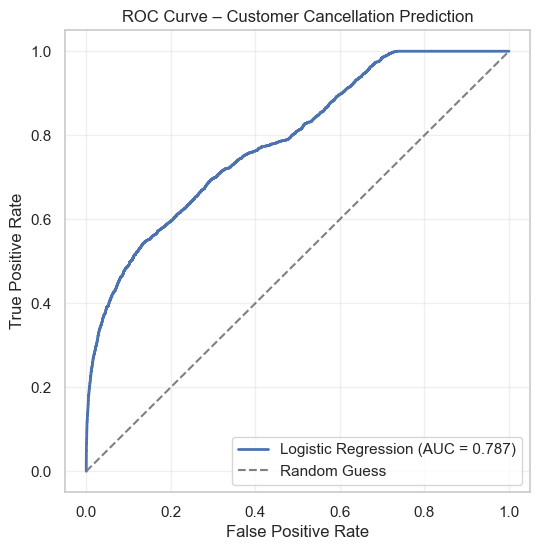

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Customer Cancellation Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()



# Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

target = 'target_customer_cancelled'

X = df.drop(columns=[target])

# drop ONLY obvious text / ID columns
drop_cols = [
    'Booking ID', 'Customer ID',
    'Pickup Location', 'Drop Location',
    'Reason for cancelling by Customer',
    'Driver Cancellation Reason',
    'Incomplete Rides Reason',
    'Date', 'Time', 'datetime'
]

X = X.drop(columns=[c for c in drop_cols if c in X.columns], errors='ignore')

# keep numeric features (this matches their RF behavior)
X = X.select_dtypes(include=[np.number])
y = df[target]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=3))

ROC AUC: 0.9594820447175286
              precision    recall  f1-score   support

           0      0.967     0.993     0.979     27900
           1      0.848     0.544     0.663      2100

    accuracy                          0.961     30000
   macro avg      0.907     0.768     0.821     30000
weighted avg      0.958     0.961     0.957     30000



# XGBoost

In [20]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score

target = 'target_customer_cancelled'

# 1) Use the same clean_features you used for RF
leaky_features = [
    'Avg VTAT', 'Ride Distance',
    'Booking Value', 'Customer Rating', 'Driver Ratings',
    'Booking Status', 'Payment Method',
    'missing_booking_value', 'missing_payment_method',
    'missing_driver_rating', 'missing_customer_rating',
    'is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete'
]
clean_features = [
    col for col in df.columns
    if col not in leaky_features and col != 'target_customer_cancelled'
]


X = df[clean_features]
y = df[target]

# ✅ keep numeric only (prevents hidden object columns)
X = X.select_dtypes(include=[np.number])

# 2) Split first (important for correct scale_pos_weight)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3) Impute (median) using TRAIN only
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# 4) Compute scale_pos_weight from TRAIN labels
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

# 5) Train XGBoost
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_imp, y_train)

# 6) Evaluate
y_prob = xgb_model.predict_proba(X_test_imp)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=3))


scale_pos_weight: 13.285714285714286
ROC AUC: 0.8654942652329749
              precision    recall  f1-score   support

           0      0.999     0.734     0.846     27900
           1      0.218     0.988     0.358      2100

    accuracy                          0.752     30000
   macro avg      0.609     0.861     0.602     30000
weighted avg      0.944     0.752     0.812     30000

